**Name-Ujjawal chauhan 
roll no-62 'B'
cu24250259
Labsheet=06**

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [16]:
img = cv2.imread("coin1.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print("Image loaded successfully")
print("Image Size:", img.shape)

Image loaded successfully
Image Size: (1500, 1500, 3)


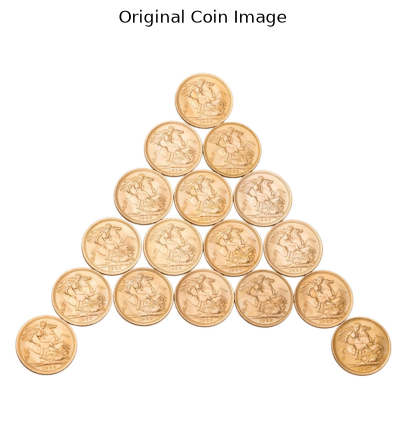

In [17]:
plt.figure(figsize=(7,5))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Coin Image")
plt.axis("off")
plt.show()

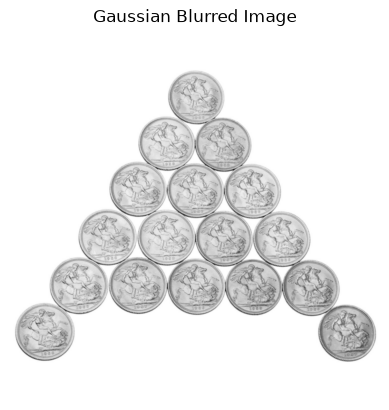

In [18]:
blur = cv2.GaussianBlur(gray, (5,5), 0)

plt.imshow(blur, cmap="gray")
plt.title("Gaussian Blurred Image")
plt.axis("off")
plt.show()

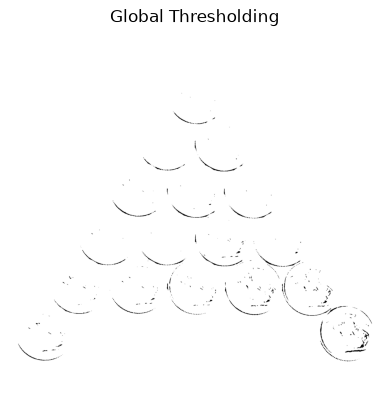

In [19]:
_, global_thresh = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY)

plt.imshow(global_thresh, cmap="gray")
plt.title("Global Thresholding")
plt.axis("off")
plt.show()

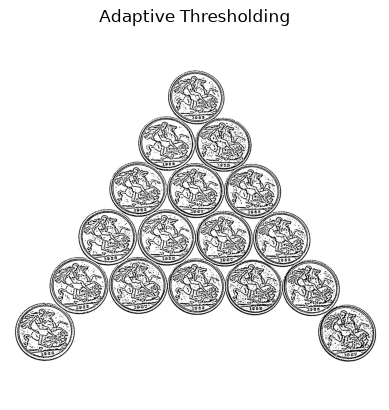

In [20]:
adaptive = cv2.adaptiveThreshold(
    blur, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11, 2
)

plt.imshow(adaptive, cmap="gray")
plt.title("Adaptive Thresholding")
plt.axis("off")
plt.show()

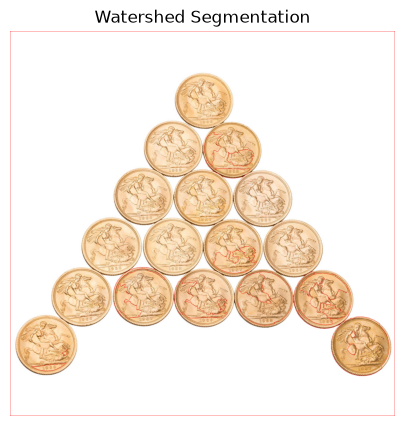

In [21]:
binary = cv2.threshold(
    blur, 0, 255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)[1]

kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(
    binary, cv2.MORPH_OPEN, kernel, iterations=2
)

sure_bg = cv2.dilate(opening, kernel, iterations=3)

dist = cv2.distanceTransform(
    opening, cv2.DIST_L2, 5
)

_, sure_fg = cv2.threshold(
    dist, 0.5 * dist.max(), 255, 0
)

sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

watershed_img = img.copy()
markers = cv2.watershed(watershed_img, markers)

watershed_img[markers == -1] = [0, 0, 255]

plt.figure(figsize=(7,5))
plt.imshow(cv2.cvtColor(watershed_img, cv2.COLOR_BGR2RGB))
plt.title("Watershed Segmentation")
plt.axis("off")
plt.show()

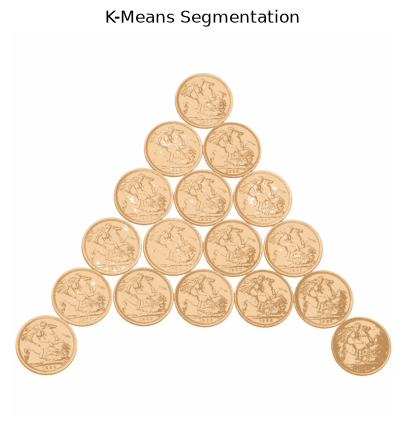

In [22]:
data = img.reshape((-1, 3))
data = np.float32(data)

k = 3

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(data)
centers = np.uint8(kmeans.cluster_centers_)

segmented = centers[labels]
segmented = segmented.reshape(img.shape)

plt.figure(figsize=(7,5))
plt.imshow(cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB))
plt.title("K-Means Segmentation")
plt.axis("off")
plt.show()

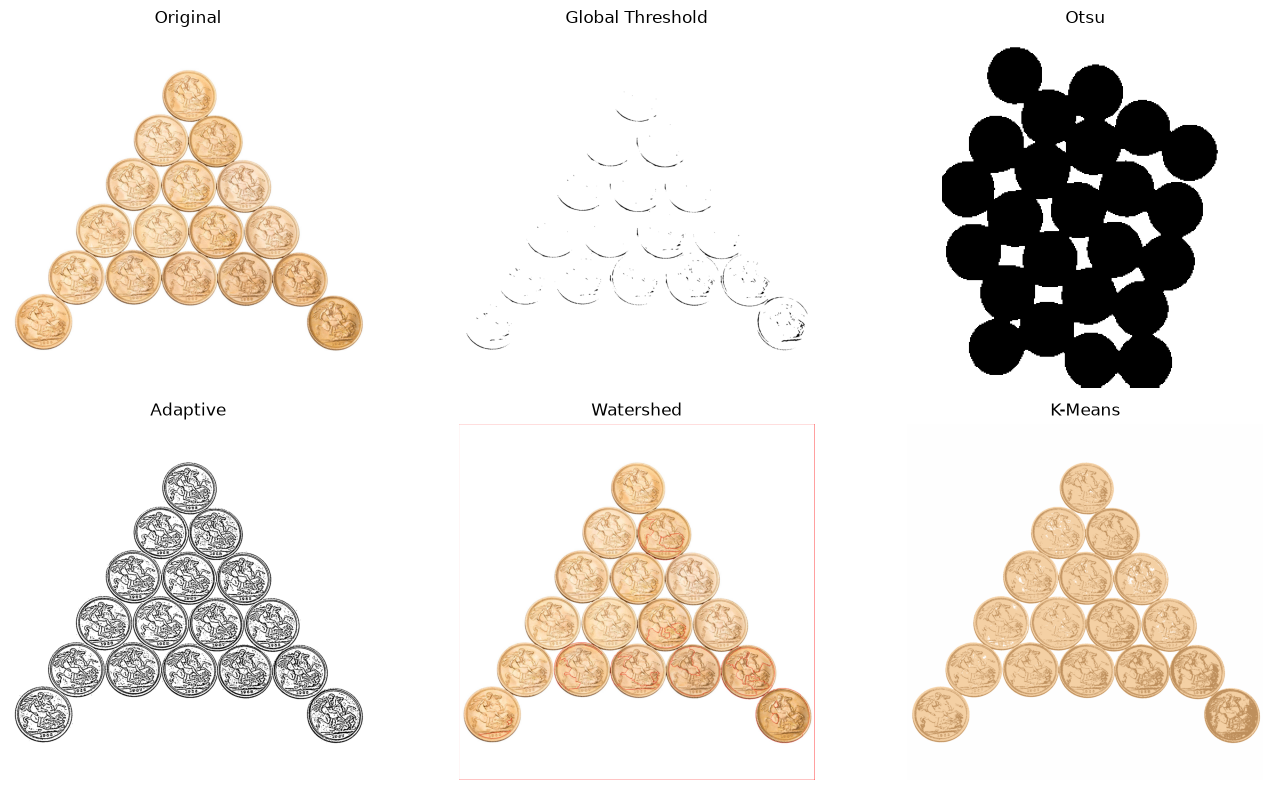

In [23]:
plt.figure(figsize=(14,8))

plt.subplot(2,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(global_thresh, cmap="gray")
plt.title("Global Threshold")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(otsu, cmap="gray")
plt.title("Otsu")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(adaptive, cmap="gray")
plt.title("Adaptive")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(cv2.cvtColor(watershed_img, cv2.COLOR_BGR2RGB))
plt.title("Watershed")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB))
plt.title("K-Means")
plt.axis("off")

plt.tight_layout()
plt.show()

In [24]:
print("OBSERVATIONS")
print("1. Global thresholding separates the coins based on intensity.")
print("2. Otsu automatically selects an optimal threshold.")
print("3. Adaptive thresholding works better with uneven illumination.")
print("4. Watershed separates touching and overlapping coins.")
print("5. K-Means segments the image based on pixel color/intensity.")

OBSERVATIONS
1. Global thresholding separates the coins based on intensity.
2. Otsu automatically selects an optimal threshold.
3. Adaptive thresholding works better with uneven illumination.
4. Watershed separates touching and overlapping coins.
5. K-Means segments the image based on pixel color/intensity.
